# Source A — How Much Is In the Shape of an Article

**The question:** how much of a county can be recovered from the *shape* of its
Wikipedia article — how many sections, how long, which ones, in what order, how
far from the county template, and what the characters look like — without
reading a word for meaning?

**Why no number here is reported in one framing.** Round one reported +0.00269
mean lift for article shape and it was arithmetically correct. It was also
misleading, because the baseline it was measured against controlled for county
size *linearly, in logs*, and an information-free curve on those same size
columns scores +0.01748 through the identical protocol. The number was right;
its framing was invisible. So:

- **`r2_alone`** — the block as the only predictor, no controls. How much of a
  county is recoverable from article shape, size and geography included.
- **`lift` (linear)** — over the linear size-plus-state baseline. Comparable to
  §13–§23.
- **`lift` (flexible)** — over the curvature-augmented baseline. The strict
  reading, and it comes with **two denominators**: the flexible baseline
  degrades on 6 of the 28 targets, so "all 28" and "the undegraded 22" are both
  honest baskets and they disagree on significance. §23.6 forbids quoting either
  alone, so both appear everywhere a flexible number does.

**Why a boost lift additionally carries `vs_boost_floor`.** Every boost lift in
this notebook is negative, and it is worth being precise about why, because the
obvious explanation is wrong. It is *not* that the two learners are measured
against different baselines: `score_target` computes one `r2_baseline` and one
`r2_flexible` per target and subtracts those same two numbers from the ridge
arms and the boost arms alike. There is no boost baseline in this round at all.
Nor is it imputation — the ridge path does impute inside its pipeline where
HistGradientBoosting handles `NaN` natively, but `shape_v1` and `shape_v2`
contain zero missing cells and carry the offset anyway.

What the negative numbers measure is the boosting estimator's **overfitting cost
on the residual target**. Fitted to what a size-plus-state model could not
explain, boosting finds structure in fold noise where `RidgeCV`'s nested
penalty search shrinks toward zero. That cost is a function of how wide the
block is, so it cannot be read off a single number: each arm is compared to a
block of pure Gaussian noise **at that arm's own width**, run through the
identical boost path under the identical folds. `vs_boost_floor` is that
comparison, and it is the only reading here that says whether an arm carries
anything a same-shaped block of noise does not.

Two arms are not findings and are labelled so wherever they appear:
`shape_v1` re-scores round one's block as a regression check, and
`size_nonlinear` is the information-free null control that prices the unit.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
DATA, ANALYSIS, OUTPUTS = REPO / "data", REPO / "analysis-output", REPO / "outputs"
SOURCE_A = ANALYSIS / "source-a"

mpl.rcParams.update({"figure.figsize": (11, 5.5), "figure.dpi": 110, "axes.grid": True,
                     "axes.axisbelow": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

profile = pd.read_parquet(DATA / "source_a_shape_profile.parquet")
structure = pd.read_parquet(DATA / "source_a_structure_features.parquet")
feature_stats = json.loads((SOURCE_A / "source_a_shape_profile_stats.json").read_text())
stats = json.loads((SOURCE_A / "source_a_shape_profile_stats_scoring.json").read_text())
scores = pd.read_csv(OUTPUTS / "source_a_shape_profile_scores.csv")
by_pillar = pd.read_csv(OUTPUTS / "source_a_shape_profile_by_pillar.csv")

profile_cols = [c for c in profile.columns if c != "fips_code"]
v1_cols = [c for c in structure.columns if c != "fips_code"]

print(f"{feature_stats['n_counties']:,} counties")
print(f"shape_v1 {stats['n_shape_v1_features']} cols + profile {stats['n_shape_profile_features']} "
      f"= shape_v2 {stats['n_shape_v2_features']} cols, vs typed {stats['n_typed_features']}")
print(f"{stats['n_targets']} targets | modal skeleton: {len(feature_stats['modal_title_set'])} titles")

3,144 counties
shape_v1 64 cols + profile 73 = shape_v2 137 cols, vs typed 29
28 targets | modal skeleton: 14 titles


## Part one — the four new families

Round one measured how many sections an article has, how long they are, and
which titles are present. These four families measure things it never looked at.

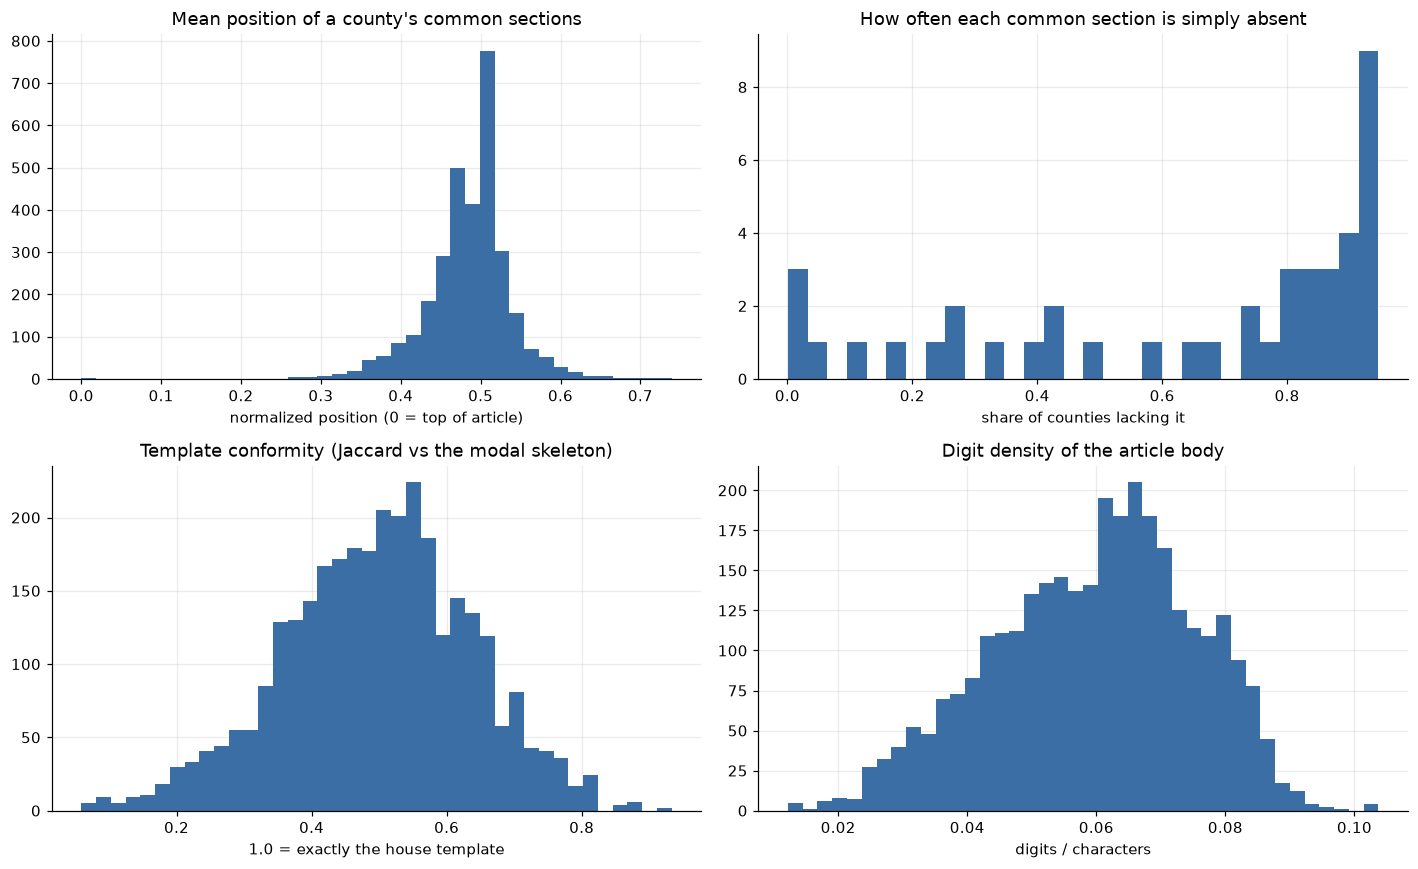

median template conformity 0.500; median digit density 0.061
660 of 3,144 counties (21.0%) have an economy-bucket section at all.
Among those 660, a narrative section precedes it in 91.2% (602 counties).
Over the whole corpus that is 19.1% -- which is the column's mean, and is NOT '81% of counties lead with economy': 2,484 counties have no economy section to lead with.


In [2]:
POSITION_ABSENT = feature_stats["position_absent_sentinel"]
pos_cols = [c for c in profile_cols if c.startswith("pos_") and not c.startswith("pos_first_")
            and c != "pos_longest_section"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

present = profile[pos_cols].replace(POSITION_ABSENT, np.nan)
axes[0, 0].hist(present.mean(axis=1).dropna(), bins=40, color="#3b6ea5")
axes[0, 0].set_title("Mean position of a county's common sections")
axes[0, 0].set_xlabel("normalized position (0 = top of article)")

absent_share = (profile[pos_cols] == POSITION_ABSENT).mean().sort_values()
axes[0, 1].hist(absent_share, bins=30, color="#3b6ea5")
axes[0, 1].set_title("How often each common section is simply absent")
axes[0, 1].set_xlabel("share of counties lacking it")

axes[1, 0].hist(profile["template_jaccard"], bins=40, color="#3b6ea5")
axes[1, 0].set_title("Template conformity (Jaccard vs the modal skeleton)")
axes[1, 0].set_xlabel("1.0 = exactly the house template")

axes[1, 1].hist(profile["digit_density"], bins=40, color="#3b6ea5")
axes[1, 1].set_title("Digit density of the article body")
axes[1, 1].set_xlabel("digits / characters")

fig.tight_layout()
plt.show()

print(f"median template conformity {profile['template_jaccard'].median():.3f}; "
      f"median digit density {profile['digit_density'].median():.3f}")
has_economy = profile["pos_first_economy"] != POSITION_ABSENT
precedes = profile["history_before_economy"] == 1.0
print(f"{has_economy.sum():,} of {len(profile):,} counties ({has_economy.mean():.1%}) have an "
      "economy-bucket section at all.")
print(f"Among those {has_economy.sum():,}, a narrative section precedes it in "
      f"{precedes[has_economy].mean():.1%} ({precedes[has_economy].sum():,} counties).")
print(f"Over the whole corpus that is {precedes.mean():.1%} -- which is the column's mean, and "
      "is NOT '81% of counties lead with economy': "
      f"{(~has_economy).sum():,} counties have no economy section to lead with.")

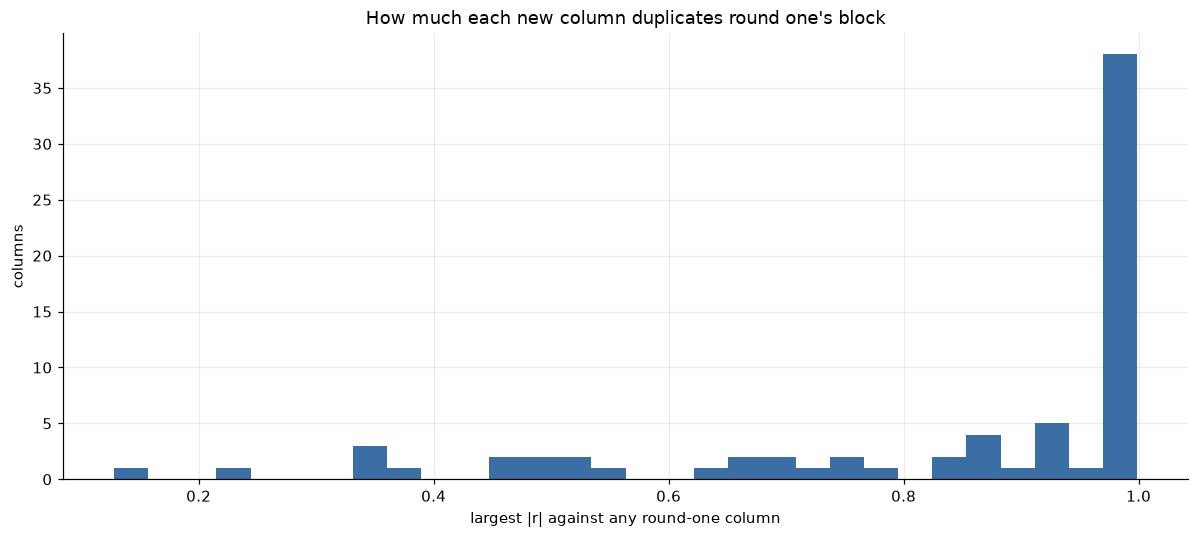

10 of 73 new columns stay under |r| = 0.5 against everything round one already had.
Most duplicated: pos_protected_areas, pos_notable_people, pos_population_ranking
Most novel: digit_density_lists, position_spread, pos_demographics


In [3]:
merged = structure.merge(profile, on="fips_code", validate="one_to_one")
cross = pd.Series(
    {c: merged[v1_cols].corrwith(merged[c]).abs().max() for c in profile_cols}
).sort_values()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(cross, bins=30, color="#3b6ea5")
ax.set_title("How much each new column duplicates round one's block")
ax.set_xlabel("largest |r| against any round-one column")
ax.set_ylabel("columns")
fig.tight_layout()
plt.show()

print(f"{(cross < 0.5).sum()} of {len(cross)} new columns stay under |r| = 0.5 against everything "
      "round one already had.")
print("Most duplicated:", ", ".join(cross.tail(3).index))
print("Most novel:", ", ".join(cross.head(3).index))

## Part two — how much of county size is *in* the block

§23 closed on an open problem. Its per-column size audit came back clean — no
single structural column is a hidden curved size proxy — while the block as a
whole demonstrably carried size. Both are true: the dependence is **joint across
columns**, and no per-column statistic can see it.

So invert the question. Instead of asking whether each column looks like size,
ask how much of county size the whole block can reconstruct. One number, no
statistics argument, and it bounds how much of any lift below could be size in
disguise.

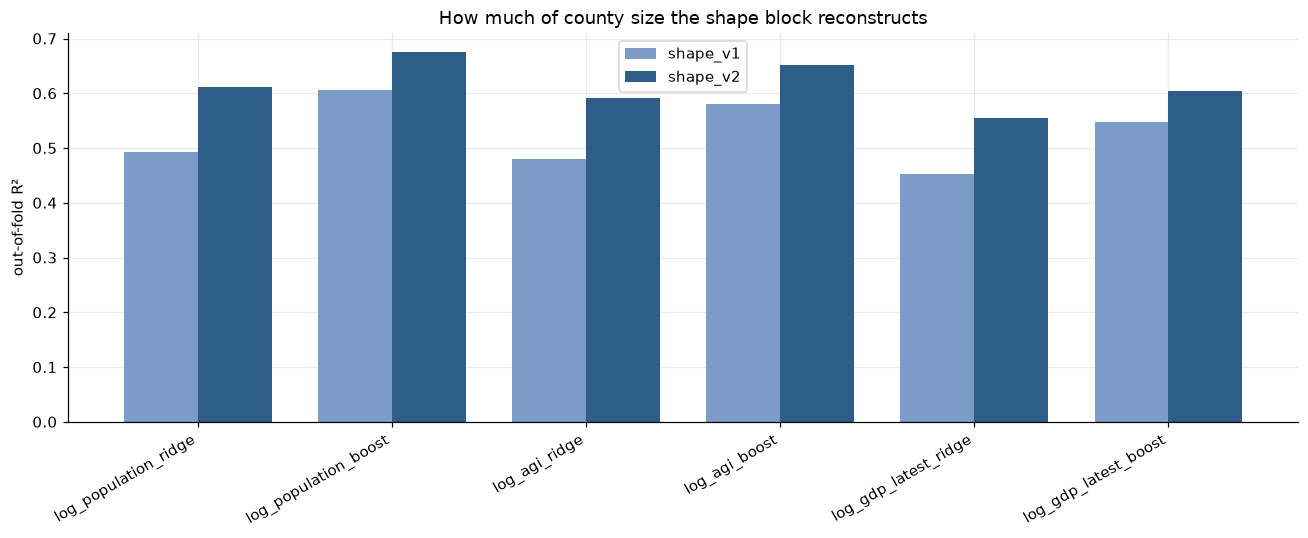

,log_population_ridge,log_population_boost,log_agi_ridge,log_agi_boost,log_gdp_latest_ridge,log_gdp_latest_boost
shape_v1,0.4934,0.606,0.4798,0.5805,0.4528,0.5471
shape_v2,0.6107,0.676,0.5913,0.6509,0.5551,0.6039


Peak: 0.676 — shape_v2 reconstructing log_population_boost.
So article shape encodes county size to R² = 0.676. Any lift below is what remains after a control has already removed size — read it with that in mind.


In [4]:
recovery = pd.DataFrame(stats["size_recoverability"]).T

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(recovery.columns))
width = 0.38
for offset, block, color in zip((-width / 2, width / 2), recovery.index, ("#7a9cc6", "#2f5d8a")):
    ax.bar(x + offset, recovery.loc[block], width, label=block, color=color)
ax.set_xticks(x)
ax.set_xticklabels(recovery.columns, rotation=30, ha="right")
ax.set_ylabel("out-of-fold R²")
ax.set_title("How much of county size the shape block reconstructs")
ax.legend()
fig.tight_layout()
plt.show()

display(recovery.round(4))

peak = recovery.max().max()
where = recovery.stack().idxmax()
print(f"Peak: {peak:.3f} — {where[0]} reconstructing {where[1]}.")
print(f"So article shape encodes county size to R² = {peak:.3f}. Any lift below is what "
      "remains after a control has already removed size — read it with that in mind.")

## Part three — the arms

Five arms, two learners, three framings, and no arm reported in fewer than all
three. `shape_v1` is a regression check on round one's block; `size_nonlinear` is
the information-free null control. Neither is a finding.

**Reading the boost rows.** `lift_linear` and `lift_flexible` are negative for
every boost arm in the table below. That is not a different baseline — both
learners are differenced against the same OLS baseline — and it is not
imputation. It is what boosting costs itself by overfitting the residual target
where ridge shrinks. Since that cost grows with block width, each arm is priced
against a Gaussian noise block of its own width (`floor` and `floor_width` in
the table): `d_linear_vs_floor` / `d_flexible_vs_floor` are how far the arm sits
*above* its own floor, and `p_linear_vs_floor` / `p_flexible_vs_floor` say
whether that distance is distinguishable from zero. Those are the only columns
here that test a boost arm.

**Reading the flexible columns.** `lift_flexible` is the all-28 reading;
`lift_flexible_undeg22` is the same quantity over the 22 targets the flexible
baseline did not degrade. §23.6 forbids quoting either without the other, so
both are in the table and neither is the headline.

In [5]:
def _arm_row(name: str, a: dict) -> dict:
    linear, flexible = a["linear"], a["flexible"]
    undegraded = flexible["undegraded"]
    arm_key = name.rsplit("_", 1)[0]
    row = {
        "arm": name,
        "learner": a["learner"],
        "r2_alone": a["mean_r2_alone"],
        "lift_linear": linear["mean_lift"],
        "p_linear_vs_baseline": linear["vs_baseline"]["wilcoxon_p"],
        "lift_flexible": flexible["mean_lift"],
        "p_flexible_vs_baseline": flexible["vs_baseline"]["wilcoxon_p"],
        f"lift_flexible_undeg{undegraded['n_targets']}": undegraded["mean_lift"],
        f"p_flexible_undeg{undegraded['n_targets']}": undegraded["vs_baseline"]["wilcoxon_p"],
    }
    if "vs_arm" in linear:
        row["vs_arm"] = linear["vs_arm"]["compared_against"]
        row["p_linear_vs_arm"] = linear["vs_arm"]["wilcoxon_p"]
        row["p_flexible_vs_arm"] = flexible["vs_arm"]["wilcoxon_p"]
    if "vs_boost_floor" in linear:
        row["floor_width"] = stats["boost_floor"][arm_key]["width"]
        row["floor_linear"] = stats["boost_floor"][arm_key]["linear"]["mean_lift"]
        row["d_linear_vs_floor"] = linear["vs_boost_floor"]["mean_paired_difference"]
        row["p_linear_vs_floor"] = linear["vs_boost_floor"]["wilcoxon_p"]
        row["floor_flexible"] = stats["boost_floor"][arm_key]["flexible"]["mean_lift"]
        row["d_flexible_vs_floor"] = flexible["vs_boost_floor"]["mean_paired_difference"]
        row["p_flexible_vs_floor"] = flexible["vs_boost_floor"]["wilcoxon_p"]
    return row


arms = pd.DataFrame([_arm_row(name, a) for name, a in stats["arms"].items()])
display(arms.round(5))

print(f"The flexible baseline degraded {len(stats['flexible_degraded_targets'])} of "
      f"{stats['n_targets']} targets, so every flexible figure has two denominators:")
print("  " + ", ".join(stats["flexible_degraded_targets"]))
print()
print("Width-matched boost floor -- an information-free Gaussian block at each arm's own width,")
print("scored through the identical boost path. Read every _boost lift against ITS OWN row:")
for arm_key, entry in stats["boost_floor"].items():
    print(f"  {arm_key:22} w={entry['width']:>4}  linear {entry['linear']['mean_lift']:+.5f}"
          f"  flexible {entry['flexible']['mean_lift']:+.5f}")

,arm,learner,r2_alone,lift_linear,p_linear_vs_baseline,lift_flexible,p_flexible_vs_baseline,lift_flexible_undeg22,p_flexible_undeg22,floor_width,floor_linear,d_linear_vs_floor,p_linear_vs_floor,floor_flexible,d_flexible_vs_floor,p_flexible_vs_floor,vs_arm,p_linear_vs_arm,p_flexible_vs_arm
0,shape_v1_ridge,ridge,0.08363,0.00269,0.00117,0.00073,0.02805,0.00062,0.20993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,shape_v1_boost,boost,0.06259,-0.05867,0.00000,-0.05932,0.00000,-0.06414,0.00000,64.0,-0.06859,0.00991,0.00655,-0.06068,0.00136,0.47910,NaN,NaN,NaN
2,shape_v2_ridge,ridge,0.09132,0.00260,0.00129,0.00084,0.00478,0.00076,0.02292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,shape_v1,0.45148,0.45148
3,shape_v2_boost,boost,0.08365,-0.04959,0.00000,-0.05074,0.00000,-0.05549,0.00000,137.0,-0.06811,0.01852,0.00079,-0.06275,0.01200,0.00142,shape_v1,0.00266,0.00886
4,typed_ridge,ridge,0.04771,0.00307,0.00038,0.00161,0.01102,0.00148,0.12888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,typed_boost,boost,-0.00442,-0.05521,0.00000,-0.05611,0.00000,-0.06048,0.00000,29.0,-0.07489,0.01968,0.00000,-0.06726,0.01115,0.00065,NaN,NaN,NaN
6,typed_plus_shape_v2_ridge,ridge,0.10216,0.00513,0.00000,0.00225,0.00155,0.00199,0.02292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,typed,0.05639,0.09002
7,typed_plus_shape_v2_boost,boost,0.09988,-0.04426,0.00000,-0.04688,0.00000,-0.05263,0.00000,166.0,-0.06674,0.02248,0.00008,-0.05991,0.01303,0.00478,typed,0.01911,0.01102
8,size_nonlinear_ridge,ridge,0.17064,0.01748,0.00000,0.00000,0.11282,0.00000,0.52021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,size_nonlinear_boost,boost,0.11481,-0.03296,0.00097,-0.06146,0.00000,-0.06837,0.00000,9.0,-0.08518,0.05222,0.00000,-0.08260,0.02114,0.00002,NaN,NaN,NaN


The flexible baseline degraded 6 of 28 targets, so every flexible figure has two denominators:
  capital_to_wage_ratio, distress_count, lq_emp_31-33, out_partner_hhi, unemployment_rate_latest, unemployment_velocity

Width-matched boost floor -- an information-free Gaussian block at each arm's own width,
scored through the identical boost path. Read every _boost lift against ITS OWN row:
  shape_v1               w=  64  linear -0.06859  flexible -0.06068
  shape_v2               w= 137  linear -0.06811  flexible -0.06275
  typed                  w=  29  linear -0.07489  flexible -0.06726
  typed_plus_shape_v2    w= 166  linear -0.06674  flexible -0.05991
  size_nonlinear         w=   9  linear -0.08518  flexible -0.08260


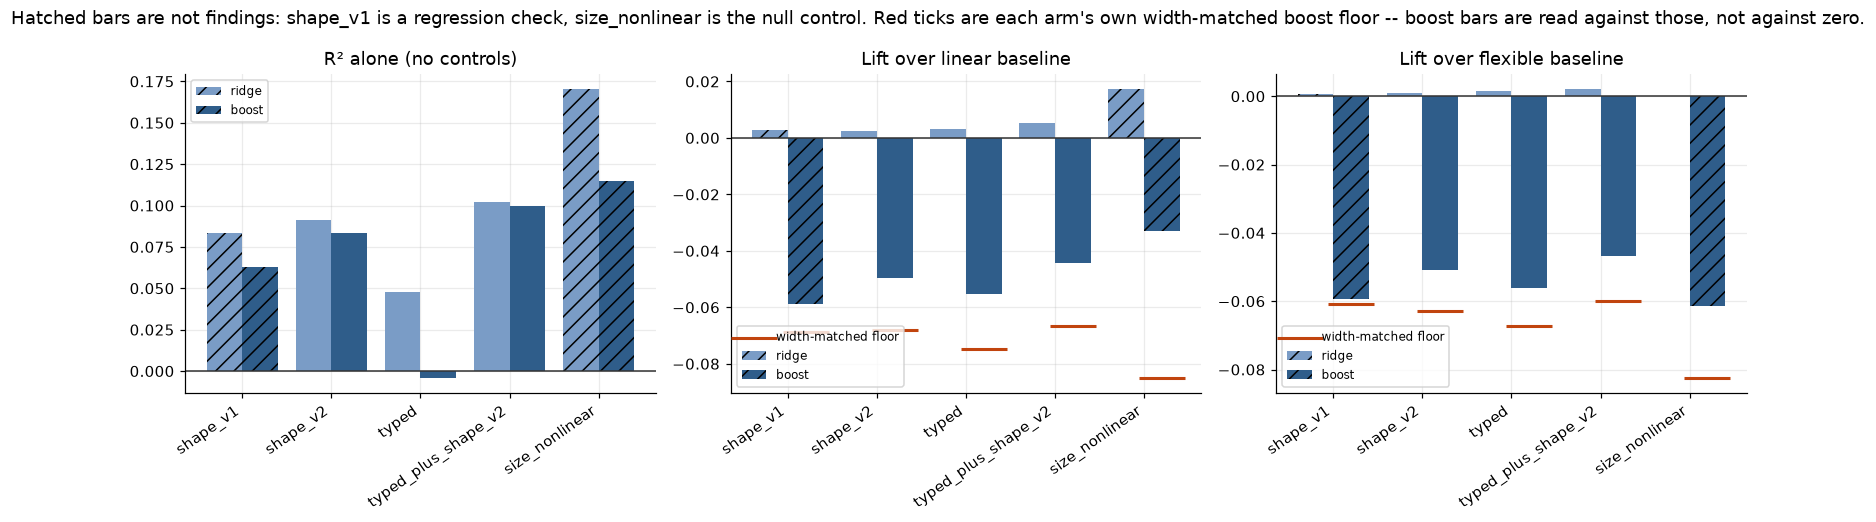

In [6]:
ridge_arms = arms[arms["learner"] == "ridge"]
arm_keys = [n.replace("_ridge", "") for n in ridge_arms["arm"]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, column, title in zip(
    axes,
    ("r2_alone", "lift_linear", "lift_flexible"),
    ("R² alone (no controls)", "Lift over linear baseline", "Lift over flexible baseline"),
):
    for offset, learner, color in zip((-0.2, 0.2), ("ridge", "boost"), ("#7a9cc6", "#2f5d8a")):
        subset = arms[arms["learner"] == learner]
        positions = np.arange(len(subset)) + offset
        bars = ax.bar(positions, subset[column], 0.4, label=learner, color=color)
        for bar, arm_name in zip(bars, subset["arm"]):
            if "size_nonlinear" in arm_name or "shape_v1" in arm_name:
                bar.set_hatch("//")
    if column != "r2_alone":
        # One floor per arm, not one line across the chart: the floor is an
        # overfitting penalty and it scales with the arm's block width.
        floor_key = "linear" if column == "lift_linear" else "flexible"
        floors = [stats["boost_floor"][k][floor_key]["mean_lift"] for k in arm_keys]
        ax.scatter(np.arange(len(arm_keys)) + 0.2, floors, marker="_", s=900,
                   color="#c1440e", lw=2, zorder=5, label="width-matched floor")
    ax.set_xticks(np.arange(len(arm_keys)))
    ax.set_xticklabels(arm_keys, rotation=35, ha="right")
    ax.axhline(0, color="#333", lw=1)
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle("Hatched bars are not findings: shape_v1 is a regression check, "
             "size_nonlinear is the null control. Red ticks are each arm's own "
             "width-matched boost floor -- boost bars are read against those, not against zero.")
fig.tight_layout()
plt.show()

### Two questions `shape_v2` answers differently

`shape_v2_ridge` under the linear framing lifts `+0.00260` over the baseline,
`vs_baseline p = 0.0013` — a real, if small, lift over the baseline that never
saw article shape at all. Compared against `shape_v1` instead, the picture
changes: `vs_arm p = 0.4515`, no distinguishable difference. Those are two
different questions — "does shape add anything over no-shape?" (yes) and "does
the round's four new families add anything over round one's block alone?" (no,
not detectably) — and the cell below prints both so neither is quoted without
the other in view.

In [7]:
v2 = stats["arms"]["shape_v2_ridge"]
v1_regression_check = stats["arms"]["shape_v1_ridge"]
print(f"shape_v2_ridge linear: mean_lift={v2['linear']['mean_lift']:+.5f}, "
      f"vs_baseline p={v2['linear']['vs_baseline']['wilcoxon_p']:.4f}, "
      f"vs_arm({v2['linear']['vs_arm']['compared_against']}) "
      f"p={v2['linear']['vs_arm']['wilcoxon_p']:.4f}")
print(f"shape_v1_ridge linear (for comparison): mean_lift={v1_regression_check['linear']['mean_lift']:+.5f}, "
      f"vs_baseline p={v1_regression_check['linear']['vs_baseline']['wilcoxon_p']:.4f}")
print()
for name in ("shape_v1_ridge", "shape_v2_ridge", "typed_ridge", "typed_plus_shape_v2_ridge",
             "size_nonlinear_ridge"):
    flexible = stats["arms"][name]["flexible"]
    undegraded = flexible["undegraded"]
    print(f"{name:26} flexible  all-{stats['n_targets']}: {flexible['mean_lift']:+.5f} "
          f"p={flexible['vs_baseline']['wilcoxon_p']:.4f} "
          f"({flexible['vs_baseline']['n_wins']}/{stats['n_targets']})   "
          f"undegraded-{undegraded['n_targets']}: {undegraded['mean_lift']:+.5f} "
          f"p={undegraded['vs_baseline']['wilcoxon_p']:.4f} "
          f"({undegraded['vs_baseline']['n_wins']}/{undegraded['n_targets']})")
print()
print("Both denominators, side by side, because they disagree: typed_ridge is significant on")
print("all 28 and not on the undegraded 22. §23.6 forbids quoting either alone.")

shape_v2_ridge linear: mean_lift=+0.00260, vs_baseline p=0.0013, vs_arm(shape_v1) p=0.4515
shape_v1_ridge linear (for comparison): mean_lift=+0.00269, vs_baseline p=0.0012

shape_v1_ridge             flexible  all-28: +0.00073 p=0.0281 (20/28)   undegraded-22: +0.00062 p=0.2099 (15/22)
shape_v2_ridge             flexible  all-28: +0.00084 p=0.0048 (23/28)   undegraded-22: +0.00076 p=0.0229 (18/22)
typed_ridge                flexible  all-28: +0.00161 p=0.0110 (18/28)   undegraded-22: +0.00148 p=0.1289 (13/22)
typed_plus_shape_v2_ridge  flexible  all-28: +0.00225 p=0.0016 (22/28)   undegraded-22: +0.00199 p=0.0229 (16/22)
size_nonlinear_ridge       flexible  all-28: +0.00000 p=0.1128 (15/28)   undegraded-22: +0.00000 p=0.5202 (10/22)

Both denominators, side by side, because they disagree: typed_ridge is significant on
all 28 and not on the undegraded 22. §23.6 forbids quoting either alone.


### Per pillar, because the aggregate is a property of the basket

Twenty of the twenty-eight targets are one QCEW table, so a basket-wide mean is
71% one pillar. Reading it as a breadth claim is a mistake this project has made
before.

Every column in the table names the baseline that produced it — `_linear` over
the size-plus-state baseline, `_flexbase` over the curvature-augmented one — so
this file cannot be opened on its own and read in a framing its reader cannot
see. That was finding I4 of the branch review: the committed CSV used to carry
the linear framing only, under column names that said so nowhere.

The boost columns are raw lifts and must be read against the per-arm floors
printed beneath the table, not against zero. The chart that follows is
restricted to the linear ridge columns: boost has no *per-pillar* floor to read
its lifts against (the floors are whole-basket, not decomposed by pillar), so a
per-pillar boost bar would repeat exactly the framing mistake `vs_boost_floor`
exists to avoid.

,pillar,n_targets,lift_shape_v1_linear,lift_shape_v1_flexbase,lift_shape_v1_linear_boost,lift_shape_v1_flexbase_boost,lift_shape_v2_linear,lift_shape_v2_flexbase,lift_shape_v2_linear_boost,lift_shape_v2_flexbase_boost,...,lift_typed_linear_boost,lift_typed_flexbase_boost,lift_typed_plus_shape_v2_linear,lift_typed_plus_shape_v2_flexbase,lift_typed_plus_shape_v2_linear_boost,lift_typed_plus_shape_v2_flexbase_boost,lift_size_nonlinear_linear,lift_size_nonlinear_flexbase,lift_size_nonlinear_linear_boost,lift_size_nonlinear_flexbase_boost
0,B,20,0.00314,0.00086,-0.06830,-0.06879,0.00287,0.00098,-0.05861,-0.05923,...,-0.06188,-0.06251,0.00556,0.00248,-0.05449,-0.05614,0.02010,0.0,-0.04412,-0.07298
1,C,3,0.00130,0.00065,-0.04018,-0.03702,0.00141,0.00092,-0.03538,-0.03124,...,-0.04574,-0.04652,0.00288,0.00219,-0.02805,-0.03026,0.00177,0.0,-0.04193,-0.05268
2,D,3,0.00000,0.00000,-0.02621,-0.03235,0.00005,0.00002,-0.02013,-0.02728,...,-0.04148,-0.03655,0.00055,0.00019,-0.01444,-0.01787,0.02107,0.0,-0.01638,-0.03725
3,E,1,0.00179,0.00075,-0.03588,-0.03069,0.00152,-0.00009,-0.03150,-0.04090,...,-0.02279,-0.02299,0.00445,0.00249,-0.02046,-0.03710,0.00001,0.0,0.06478,-0.00344
4,F,1,0.00671,0.00061,-0.04175,-0.04641,0.00946,0.00112,-0.01847,-0.01975,...,-0.02386,-0.04861,0.01778,0.00374,-0.00162,-0.00837,0.01892,-0.0,0.06978,0.01203


Every column above names its baseline: _linear over the size-plus-state baseline,
_flexbase over the curvature-augmented one. Boost floors are per arm and whole-basket,
not decomposed by pillar:
  shape_v1               w=  64  linear -0.06859  flexible -0.06068
  shape_v2               w= 137  linear -0.06811  flexible -0.06275
  typed                  w=  29  linear -0.07489  flexible -0.06726
  typed_plus_shape_v2    w= 166  linear -0.06674  flexible -0.05991
  size_nonlinear         w=   9  linear -0.08518  flexible -0.08260


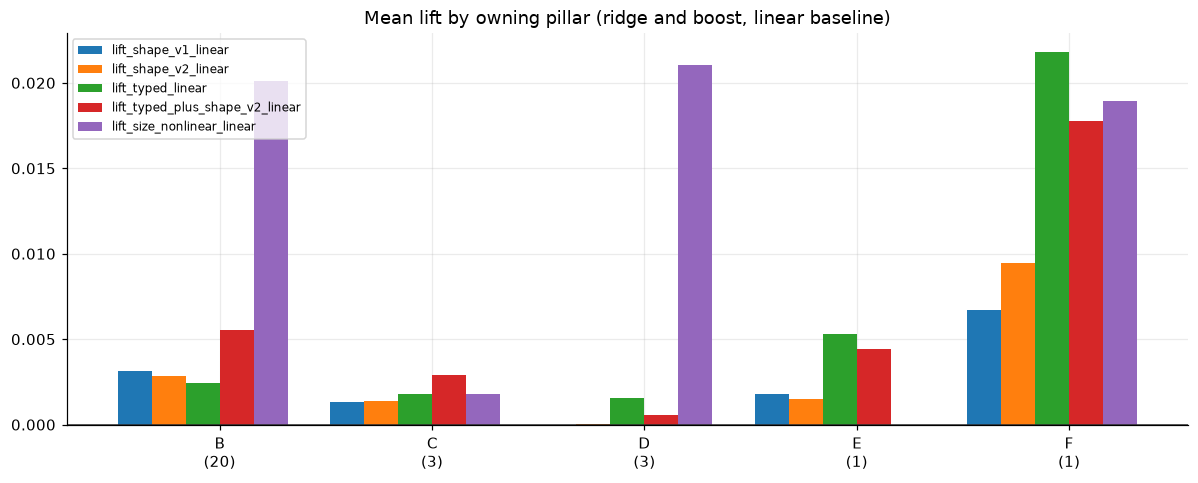

In [8]:
display(by_pillar.round(5))

print("Every column above names its baseline: _linear over the size-plus-state baseline,")
print("_flexbase over the curvature-augmented one. Boost floors are per arm and whole-basket,")
print("not decomposed by pillar:")
for arm_key, entry in stats["boost_floor"].items():
    print(f"  {arm_key:22} w={entry['width']:>4}  linear {entry['linear']['mean_lift']:+.5f}"
          f"  flexible {entry['flexible']['mean_lift']:+.5f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
keys = [c for c in by_pillar.columns if c.endswith("_linear")]
x = np.arange(len(by_pillar))
width = 0.8 / len(keys)
for i, key in enumerate(keys):
    ax.bar(x + i * width - 0.4, by_pillar[key], width, label=key)
ax.set_xticks(x)
ax.set_xticklabels([f"{p}\n({n})" for p, n in zip(by_pillar["pillar"], by_pillar["n_targets"])])
ax.axhline(0, color="#333", lw=1)
ax.set_title("Mean lift by owning pillar (ridge and boost, linear baseline)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Part four — where the ceiling is

The targets article shape predicts best on its own, and what survives as the
control tightens. The gap between the first column and the last is the answer to
"how much of this is really about the article."

,pillar,label,n,r2_alone_shape_v2,r2_alone_shape_v2_boost,lift_shape_v2,lift_shape_v2_flexbase
0,D,freight tonnage (log10),3144,0.4922,0.5481,0.0001,0.0001
1,C,unemployment rate (level),3143,0.2096,0.3015,0.0035,0.0027
2,B,"Agriculture, Forestry, Fishing & Hunting LQ",1457,0.1659,0.1261,-0.0013,0.0000
3,D,inbound partner concentration,3144,0.1486,0.1477,0.0002,0.0000
4,B,Wholesale Trade LQ,2346,0.1399,0.1618,0.0063,0.0018
5,B,"Professional, Scientific & Technical Services LQ",2268,0.1395,0.1018,0.0035,0.0000
6,B,Real Estate & Rental & Leasing LQ,2453,0.1117,0.0727,-0.0020,-0.0021
7,D,outbound partner concentration,3144,0.1091,0.1253,-0.0001,0.0000
8,B,"Mining, Quarrying, Oil & Gas LQ",1026,0.1079,0.1099,-0.0002,0.0004
9,B,Administrative & Support & Waste Management LQ,2212,0.0914,0.0863,-0.0020,-0.0020


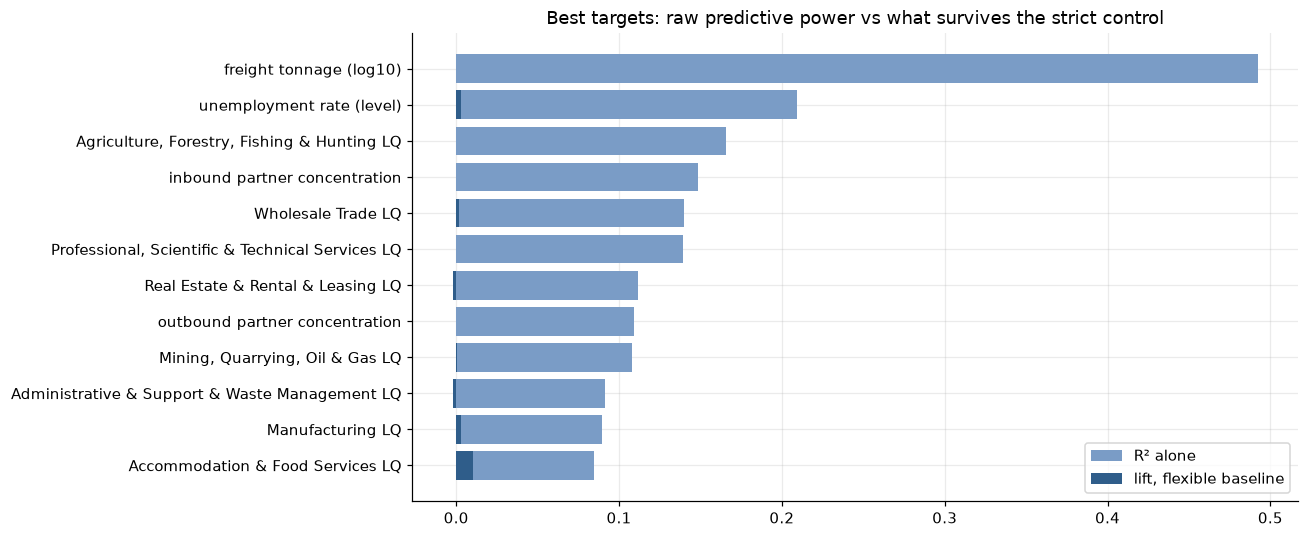

Mean R² alone across all 28 targets: 0.0913
Mean lift over the flexible baseline, all 28: +0.00084
Mean lift over the flexible baseline, undegraded 22: +0.00076


In [9]:
ceiling = scores[[
    "pillar", "label", "n",
    "r2_alone_shape_v2", "r2_alone_shape_v2_boost",
    "lift_shape_v2", "lift_shape_v2_flexbase",
]].head(12)
display(ceiling.round(4))

fig, ax = plt.subplots(figsize=(12, 5))
top = scores.head(12).iloc[::-1]
ax.barh(top["label"], top["r2_alone_shape_v2"], color="#7a9cc6", label="R² alone")
ax.barh(top["label"], top["lift_shape_v2_flexbase"], color="#2f5d8a", label="lift, flexible baseline")
ax.set_title("Best targets: raw predictive power vs what survives the strict control")
ax.legend()
fig.tight_layout()
plt.show()

undegraded_rows = scores["r2_baseline_flexible"] >= scores["r2_baseline"]
print(f"Mean R² alone across all {stats['n_targets']} targets: "
      f"{scores['r2_alone_shape_v2'].mean():.4f}")
print(f"Mean lift over the flexible baseline, all {stats['n_targets']}: "
      f"{scores['lift_shape_v2_flexbase'].mean():+.5f}")
print(f"Mean lift over the flexible baseline, undegraded {int(undegraded_rows.sum())}: "
      f"{scores.loc[undegraded_rows, 'lift_shape_v2_flexbase'].mean():+.5f}")